## Idea of this notebook is to generate LogisticRegression classifier for complex dataset, where decision boundary is not a straight line

### Goal is to visualize non-linear decision boundary

**dataset** - sklearn make_circles

Luka Jasovic jasovicluka1@gmail.com

--- 

In [541]:
import numpy as np
import seaborn as sns
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [542]:
X,y = make_circles(n_samples=300,noise=0.152)
m,n = X.shape
w_init = np.arange(X.shape[1]).reshape(-1,)
b_init = 0

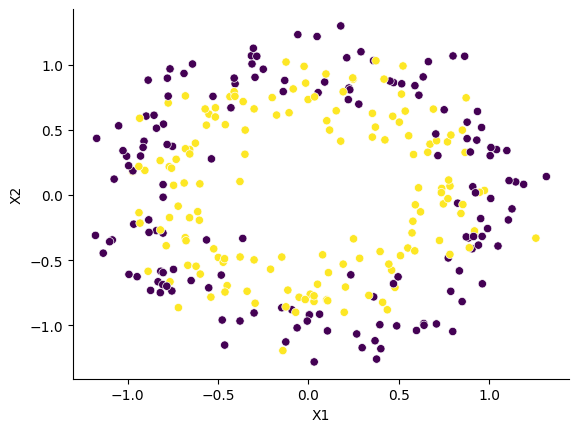

In [543]:
sns.scatterplot(x= X[:,0],y= X[:,1],c=y)
plt.xlabel('X1')
plt.ylabel('X2')
sns.despine(right=True,top=True)
plt.show()

---

LogisticRegression Loss function:

Derived from the bernouli distribution as:

P ( Y = 1 | X ) = Y_hat

P ( Y = 0 | X ) = 1 - Y_hat

With combination of these 2 we get:


Y_hat^Yi * (1 - Y_hat)^( 1 - Yi) 

- log


Yi * Log(Y_hat) * log(1 - yi)*(1 - Y_hat)


Incorporatnig this into Loss function as L(Fw,b(xi),yi) = > we get __COST__ as a sum of losses of all training examples:

COST = -1/m SUM[ yi * log(y_hat) + (1-yi) *log ( 1 - Y_hat) ]


+ With Regularization:

COST = - 1/m SUM[ yi * log(y_hat) + (1 - yi ) * log ( 1 - Y_hat) * __lambda||w||^2/n__]

In [544]:
print(X.shape)
print(w_init.shape)
print(y.shape)

(300, 2)
(2,)
(300,)


In [545]:
def get_shape(x_or_any):
    m,n = x_or_any.shape
    return m,n


In [546]:
def sigmoid(z):
    return 1/(1+np.exp(z))


In [547]:
def cost(X,y,w,b):
    f_wx = sigmoid(np.dot(X,w)+b)
    loss = np.dot(y.T,np.log(f_wx))+np.dot((1-y).T,np.log(1-f_wx))
    cost = -1/(X.shape[0])* loss
    return cost



In [548]:
print(X.shape)
print(w_init.shape)
print(y.shape)

(300, 2)
(2,)
(300,)


In [549]:
def gradients(X,y,w,b):
    m,n = get_shape(X)
    f_wx = sigmoid(np.dot(X,w)+b)
    error = f_wx - y
    dj_dw = 1/m * np.dot(X.T,error)
    dj_db = 1/m * np.sum(error)
    return dj_dw,dj_db

In [550]:
def gradient_descent(X,y,w,b,alpha,num_iter):
    m,n = get_shape(X)
    cost_history = []
    previous_cost = cost(X,y,w,b)
    for i in range(num_iter):
        dj_dw,dj_db = gradients(X,y,w,b)
        w = w - alpha*dj_dw
        b = b - alpha*dj_db
        current_cost = cost(X,y,w,b)
        cost_history.append({
            'current_cost':current_cost,
            'best_w':w,
            'best_b':b
        })
        if abs(current_cost-previous_cost)<0.00001:
            print(f"Convergence reached at {i}th iteration!\nBest W: {w}\nBest b: {b}")
            break
    return w,b,cost_history

        


In [551]:
best_w,best_b,cost_history= gradient_descent(X,y,w_init,b_init,alpha=0.001,num_iter=1000)
print(cost_history)
print(w)
print(b)

[{'current_cost': np.float64(0.7485084099341722), 'best_w': array([-5.29194417e-06,  1.00010475e+00]), 'best_b': np.float64(2.0888888090025877e-06)}, {'current_cost': np.float64(0.7485194167637025), 'best_w': array([-1.05844008e-05,  1.00020950e+00]), 'best_b': np.float64(4.178440597197103e-06)}, {'current_cost': np.float64(0.7485304255840052), 'best_w': array([-1.58773699e-05,  1.00031427e+00]), 'best_b': np.float64(6.268655506432339e-06)}, {'current_cost': np.float64(0.7485414363953702), 'best_w': array([-2.11708516e-05,  1.00041905e+00]), 'best_b': np.float64(8.359533678574608e-06)}, {'current_cost': np.float64(0.7485524491980868), 'best_w': array([-2.64648458e-05,  1.00052383e+00]), 'best_b': np.float64(1.0451075255507682e-05)}, {'current_cost': np.float64(0.748563463992445), 'best_w': array([-3.17593527e-05,  1.00062863e+00]), 'best_b': np.float64(1.2543280379132841e-05)}, {'current_cost': np.float64(0.7485744807787346), 'best_w': array([-3.70543721e-05,  1.00073343e+00]), 'best_b

## 1. Straight line decision boundary ( and why it does not work for this problem!)

In [552]:
X_m = np.linspace(np.min(X[:,0]-0.5),np.max(X[:,0]+0.5),150)
Y_m = np.linspace(np.min(X[:,1]-0.5),np.max(X[:,1]+0.5),150)
xx,yy = np.meshgrid(X_m,Y_m)

x_1d = np.ravel(xx)
y_1d = np.ravel(yy)
grid = np.stack([x_1d,y_1d],axis=1)
grid.shape

(22500, 2)

In [553]:
f_grid = sigmoid(np.dot(grid, best_w) + best_b)

### Plot:

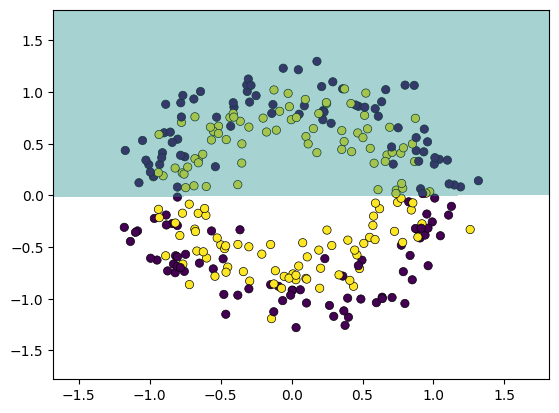

In [554]:
#original data
sns.scatterplot(x=X[:,0],y=X[:,1],c=y,edgecolor='k')

#contourplot of decision boundary
f_grid.shape
f_grid = f_grid.reshape(xx.shape) # because contourplot needs 2D not 1d!

plt.contourf(xx, yy, f_grid, levels=[0,0.5],alpha=.4)
plt.savefig('Bad decision boundary.jpg')

We this implementation I prove that:

1) **Nonlinear** problems cannot be separated with straight line or a hyperplane, ofter characterized by the overlapping classes

2. Linear models underfit these problems

**Solution**

1) adding high order powers (x1^2,x2^2) to the input features to turn nonlinear relationship into linear one in higher dimension

2) using nonlinear classifier 



### Polynomials

In [555]:
from sklearn.preprocessing import PolynomialFeatures

In [556]:
poly = PolynomialFeatures(degree=2)

In [557]:
X_poly = poly.fit_transform(X)
m,n = get_shape(X_poly)
print(n)

6


In [558]:
#Adjust w_init shape
w_init_poly = np.zeros(X_poly.shape[1])
print(w_init_poly.shape)

(6,)


In [559]:
cost_poly = cost(X_poly,y,w_init_poly,b_init)
dj_db,dj_dw = gradients(X_poly,y,w_init_poly,b_init)
best_w,best_b,history = gradient_descent(X_poly,y,w_init_poly,b_init,alpha=0.003,num_iter=1000)
print(best_w)
print(best_b)

[-0.10338163 -0.02087724  0.00901217 -0.2117605   0.01925745 -0.20435415]
-0.1033816312666555


In [560]:
X_poly = np.linspace(np.min(X[:,0]-0.5),np.max(X[:,0]+0.5),150)
Y_poly = np.linspace(np.min(X[:,1]-0.5),np.max(X[:,1]+0.5),150)
xx,yy = np.meshgrid(X_m,Y_m)

x_poly_1d = np.ravel(xx)
y_poly_1d = np.ravel(yy)
f_grid= np.stack([x_poly_1d,y_poly_1d],axis=1)
f_grid_poly = poly.fit_transform(f_grid)
f_grid_poly.shape

(22500, 6)

In [561]:
f_wx_poly = sigmoid(np.dot(f_grid_poly,best_w)+best_b)
f_wx_poly_2d = f_wx_poly.reshape(xx.shape)

C:\Users\Admin\AppData\Local\Temp\ipykernel_10640\1978092427.py:2: UserWarning: The following kwargs were not used by contour: 'color', 'linewidth'
  plt.contour(xx,yy,f_wx_poly_2d,alpha=0.9,color='k',linewidth=2)


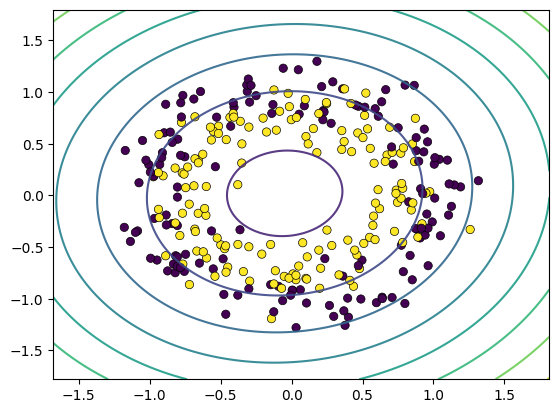

In [562]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=y,edgecolor='k')
plt.contour(xx,yy,f_wx_poly_2d,alpha=0.9,color='k',linewidth=2)
plt.savefig('Nonlinear decision boundary.jpg')